# CS3807 – Deep Learning Laboratory
## Experiment 2: MLP for Multi-Class Image Classification (Fashion-MNIST)

This notebook covers Tasks 1–5, hyperparameter optimization with `RandomizedSearchCV` + `SciKeras`,
all mandatory plots, and the baseline vs optimized comparison.

**How to use in Colab:** Runtime → Change runtime type → GPU (T4) is recommended for the hyperparameter
search section, though the notebook will also run on CPU (just slower).


In [1]:
# Install SciKeras (not preinstalled in Colab) and import libraries
!pip install -q scikeras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from scikeras.wrappers import KerasClassifier

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: []


## Task 1: Dataset Exploration

Load Fashion-MNIST, print dataset dimensions, display 10 sample images, and plot the class distribution.

In [2]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Dataset dimensions")
print("x_train:", x_train.shape, " y_train:", y_train.shape)
print("x_test :", x_test.shape,  " y_test :", y_test.shape)
print("Number of classes:", len(class_names))
print("Image size:", x_train.shape[1], "x", x_train.shape[2])


Dataset dimensions
x_train: (60000, 28, 28)  y_train: (60000,)
x_test : (10000, 28, 28)  y_test : (10000,)
Number of classes: 10
Image size: 28 x 28


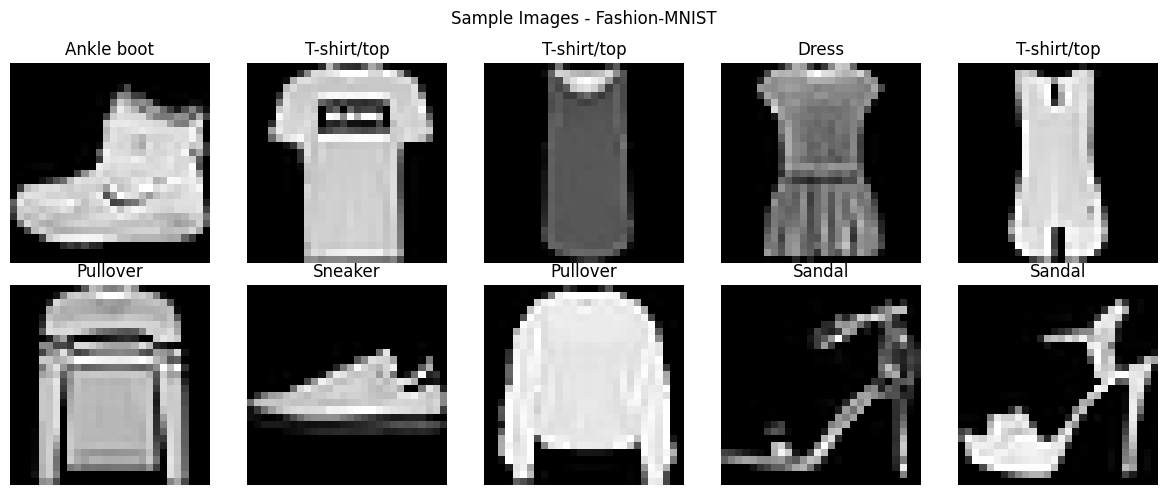

In [3]:
# Display 10 sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Images - Fashion-MNIST")
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()


**Inference (Sample Images):** The dataset contains 28x28 grayscale images of clothing items
across 10 categories. Visual inspection confirms clear but low-resolution silhouettes, meaning the model
must rely on shape and texture patterns rather than fine detail or color.

/tmp/ipykernel_3113/97643682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[u] for u in unique], y=counts, palette='viridis')


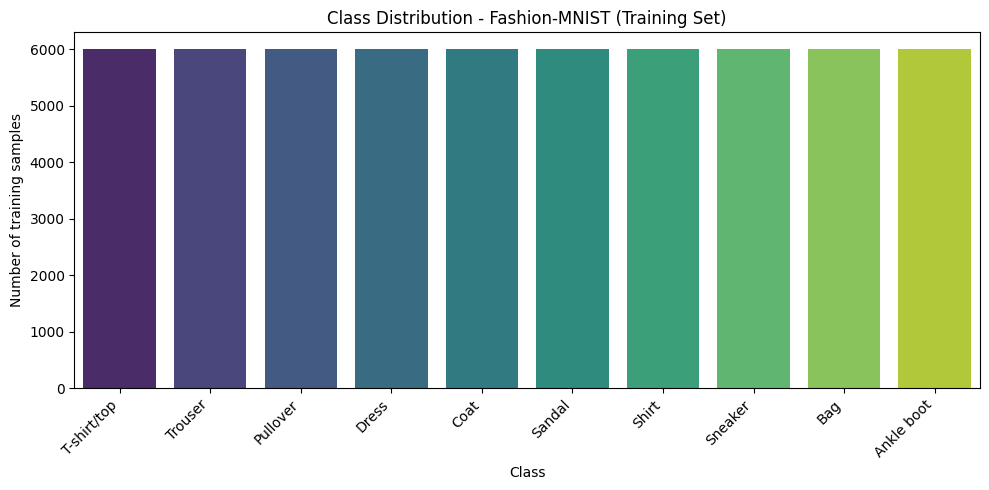

T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
dtype: int64


In [4]:
# Plot class distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=[class_names[u] for u in unique], y=counts, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Class")
plt.ylabel("Number of training samples")
plt.title("Class Distribution - Fashion-MNIST (Training Set)")
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(pd.Series(counts, index=[class_names[u] for u in unique]))


**Inference (Class Distribution):** All 10 classes contain exactly 6,000 training images each,
so the dataset is perfectly balanced. This means accuracy is a fair evaluation metric and no class
re-weighting or resampling is required.

## Task 2: Data Preprocessing

Flatten the 28x28 images into 784-length vectors, normalize pixel values to [0,1], and one-hot encode labels.

In [5]:
print("Shapes BEFORE preprocessing")
print("x_train:", x_train.shape, " y_train:", y_train.shape)
print("x_test :", x_test.shape,  " y_test :", y_test.shape)

# Flatten: 28x28 -> 784
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values to [0, 1]
x_train_norm = x_train_flat.astype('float32') / 255.0
x_test_norm = x_test_flat.astype('float32') / 255.0

# One-hot encode labels
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)

print("\nShapes AFTER preprocessing")
print("x_train_norm:", x_train_norm.shape, " y_train_oh:", y_train_oh.shape)
print("x_test_norm :", x_test_norm.shape,  " y_test_oh :", y_test_oh.shape)
print("\nPixel range check -> min:", x_train_norm.min(), "max:", x_train_norm.max())


Shapes BEFORE preprocessing
x_train: (60000, 28, 28)  y_train: (60000,)
x_test : (10000, 28, 28)  y_test : (10000,)

Shapes AFTER preprocessing
x_train_norm: (60000, 784)  y_train_oh: (60000, 10)
x_test_norm : (10000, 784)  y_test_oh : (10000, 10)

Pixel range check -> min: 0.0 max: 1.0


## Task 3: Model Construction (Baseline)

Baseline architecture: `784 -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(10, Softmax)`

In [6]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Model Training

Compile with Adam optimizer, categorical cross-entropy loss, accuracy metric.
Train for 20 epochs, batch size 32.

In [7]:
baseline_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start_time = time.time()
history = baseline_model.fit(
    x_train_norm, y_train_oh,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.8219 - loss: 0.4989 - val_accuracy: 0.8538 - val_loss: 0.3983
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8653 - loss: 0.3691 - val_accuracy: 0.8637 - val_loss: 0.3693
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8776 - loss: 0.3316 - val_accuracy: 0.8698 - val_loss: 0.3619
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8856 - loss: 0.3082 - val_accuracy: 0.8747 - val_loss: 0.3499
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8925 - loss: 0.2890 - val_accuracy: 0.8662 - val_loss: 0.3650
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8978 - loss: 0.2729 - val_accuracy: 0.8673 - val_loss: 0.3784
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9017 - loss: 0.2611 - val_accuracy: 0.8673 - val_loss: 0.3692
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9053 - loss: 0.2501

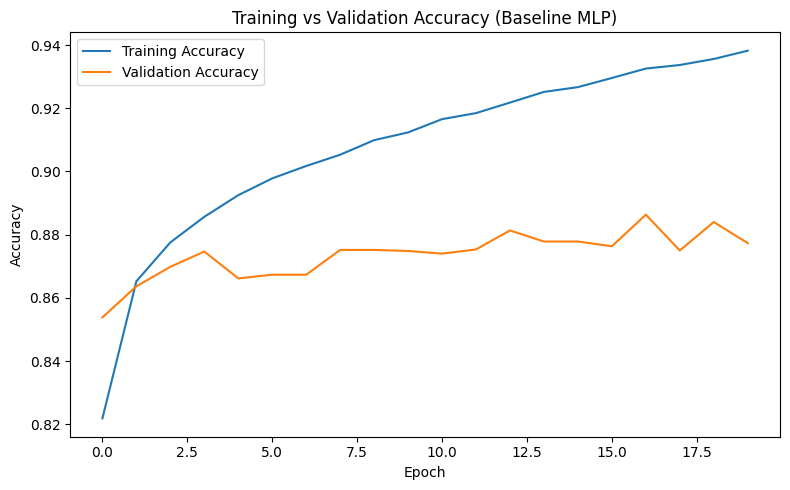

In [8]:
# Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Baseline MLP)')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_epoch.png', dpi=150)
plt.show()


**Inference (Accuracy vs Epoch):** Training accuracy rises steadily and validation accuracy
tracks closely for the first several epochs, indicating the model is learning generalizable features.
Any growing gap in later epochs would signal the onset of overfitting.

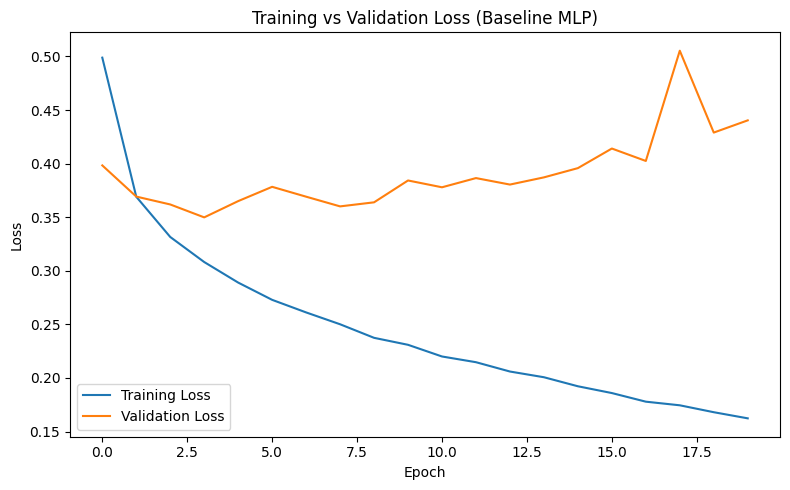

In [9]:
# Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Baseline MLP)')
plt.legend()
plt.tight_layout()
plt.savefig('loss_vs_epoch.png', dpi=150)
plt.show()


**Inference (Loss vs Epoch):** Both training and validation loss decrease and flatten out,
showing convergence. If validation loss starts increasing while training loss keeps falling, that is
the classic overfitting signature.

## Task 5: Model Evaluation

Accuracy, Precision, Recall, F1-score, Confusion Matrix, Classification Report on the test set.

In [10]:
y_pred_probs = baseline_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # original integer labels

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average='macro')
baseline_rec = recall_score(y_true, y_pred, average='macro')
baseline_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Baseline Test Accuracy : {baseline_acc:.4f}")
print(f"Baseline Precision(macro): {baseline_prec:.4f}")
print(f"Baseline Recall(macro)   : {baseline_rec:.4f}")
print(f"Baseline F1-score(macro) : {baseline_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Test Accuracy : 0.8757
Baseline Precision(macro): 0.8774
Baseline Recall(macro)   : 0.8757
Baseline F1-score(macro) : 0.8728

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.89      0.82      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.80      0.78      0.79      1000
       Dress       0.82      0.95      0.88      1000
        Coat       0.77      0.81      0.79      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.81      0.55      0.65      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.98      0.95      0.97      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



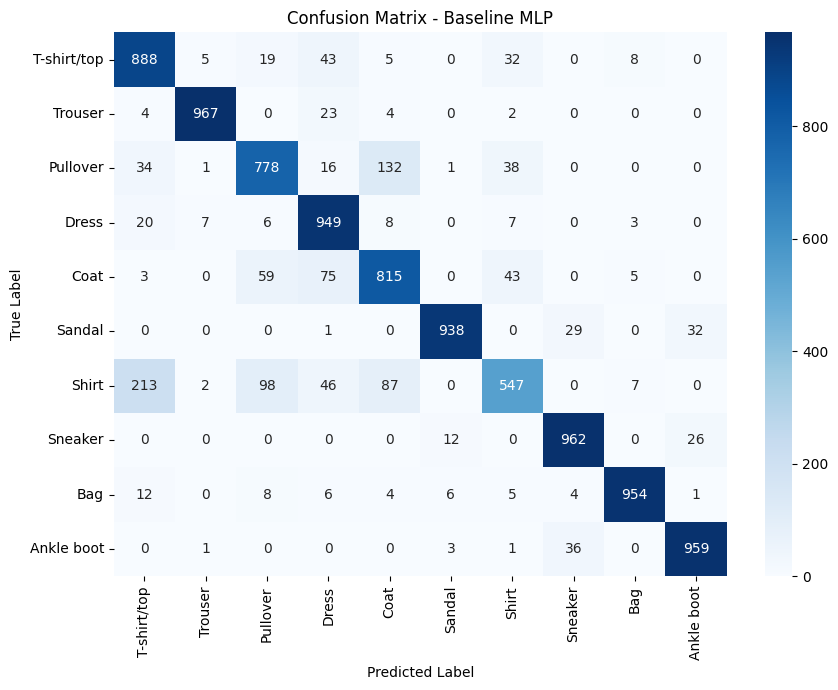

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline MLP')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()


**Inference (Confusion Matrix):** Most predictions fall on the diagonal, confirming good
overall classification. The largest confusions typically occur between visually similar classes such as
Shirt/T-shirt/Pullover/Coat, which makes sense given their similar silhouettes.

## 7. Hyperparameter Optimization

We use `RandomizedSearchCV` (recommended over exhaustive Grid Search because the full search space below
has 3 x 4 x 3 x 4 x 3 x 3 x 3 x 3 = **11,664** combinations, which is computationally infeasible to grid
search with 5-fold CV) together with the `SciKeras` wrapper around a configurable Keras model.

| Hyperparameter | Candidate Values |
|---|---|
| Hidden Layers | 1, 2, 3 |
| Hidden Neurons | 32, 64, 128, 256 |
| Learning Rate | 0.1, 0.01, 0.001 |
| Batch Size | 16, 32, 64, 128 |
| Epochs | 10, 20, 30 |
| Optimizer | SGD, Adam, RMSProp |
| Activation Function | ReLU, Tanh, Sigmoid |
| Dropout Rate | 0.0, 0.2, 0.5 |

**Note on runtime:** searching the full training set with many candidates and 5-fold CV can take a very
long time on Colab. The knobs `SEARCH_SAMPLE_SIZE`, `N_ITER`, and `CV_FOLDS` below let you trade off
runtime vs. thoroughness. Increase them if you have a GPU runtime and time to spare; the manual only
requires that 5-fold CV be used for the *final* reported search, so raise `CV_FOLDS` back to 5 for your
official run.

In [12]:
# Configurable knobs (tune these based on your available compute time)
SEARCH_SAMPLE_SIZE = 10000   # subset of training data used during the search (use x_train_norm.shape[0] for full data)
N_ITER = 20                  # number of random hyperparameter combinations to try
CV_FOLDS = 5                 # cross-validation folds (manual specifies 5-fold CV)

rng = np.random.RandomState(SEED)
search_idx = rng.choice(x_train_norm.shape[0], size=SEARCH_SAMPLE_SIZE, replace=False)
x_search = x_train_norm[search_idx]
y_search = y_train[search_idx]  # SciKeras/KerasClassifier expects integer labels, not one-hot

print("Search subset shape:", x_search.shape)


Search subset shape: (10000, 784)


In [13]:
def build_mlp(hidden_layers=1, hidden_neurons=128, learning_rate=0.001,
              optimizer_name='adam', activation='relu', dropout_rate=0.0,
              meta=None):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap with SciKeras. loss/metrics are handled inside build_mlp via model.compile,
# but KerasClassifier still needs a loss for its own bookkeeping.
clf = KerasClassifier(
    model=build_mlp,
    loss='categorical_crossentropy',
    hidden_layers=1,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer_name='adam',
    activation='relu',
    dropout_rate=0.0,
    epochs=10,
    batch_size=32,
    verbose=0,
)


In [14]:
!pip install scikit-learn==1.5.2


In [15]:
# Full search space as specified in the lab manual
param_distributions = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
}

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring='accuracy',
    random_state=SEED,
    n_jobs=1,     # keep at 1 for GPU/Colab stability
    verbose=2,
)

start_time = time.time()
random_search.fit(x_search, y_search)
search_time = time.time() - start_time
print(f"\nHyperparameter search completed in {search_time:.2f} seconds")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=  33.1s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=  15.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=  15.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=  15.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_

In [17]:
print("Best cross-validation accuracy:", random_search.best_score_)
print("\nBest hyperparameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
cv_results_sorted[['params', 'mean_test_score', 'std_test_score']].head(10)


Best cross-validation accuracy: 0.8503999999999999

Best hyperparameters:
  model__optimizer_name: adam
  model__learning_rate: 0.001
  model__hidden_neurons: 256
  model__hidden_layers: 1
  model__dropout_rate: 0.2
  model__activation: tanh
  epochs: 20
  batch_size: 64


,params,mean_test_score,std_test_score
0,"{'model__optimizer_name': 'adam', 'model__lear...",0.8504,0.011133
2,"{'model__optimizer_name': 'rmsprop', 'model__l...",0.8501,0.012076
9,"{'model__optimizer_name': 'adam', 'model__lear...",0.8481,0.004944
3,"{'model__optimizer_name': 'adam', 'model__lear...",0.8442,0.008370
4,"{'model__optimizer_name': 'adam', 'model__lear...",0.8430,0.004712
18,"{'model__optimizer_name': 'sgd', 'model__learn...",0.8418,0.008054
8,"{'model__optimizer_name': 'adam', 'model__lear...",0.8414,0.017371
7,"{'model__optimizer_name': 'adam', 'model__lear...",0.8410,0.012732
11,"{'model__optimizer_name': 'rmsprop', 'model__l...",0.8398,0.014538
16,"{'model__optimizer_name': 'rmsprop', 'model__l...",0.8279,0.006771


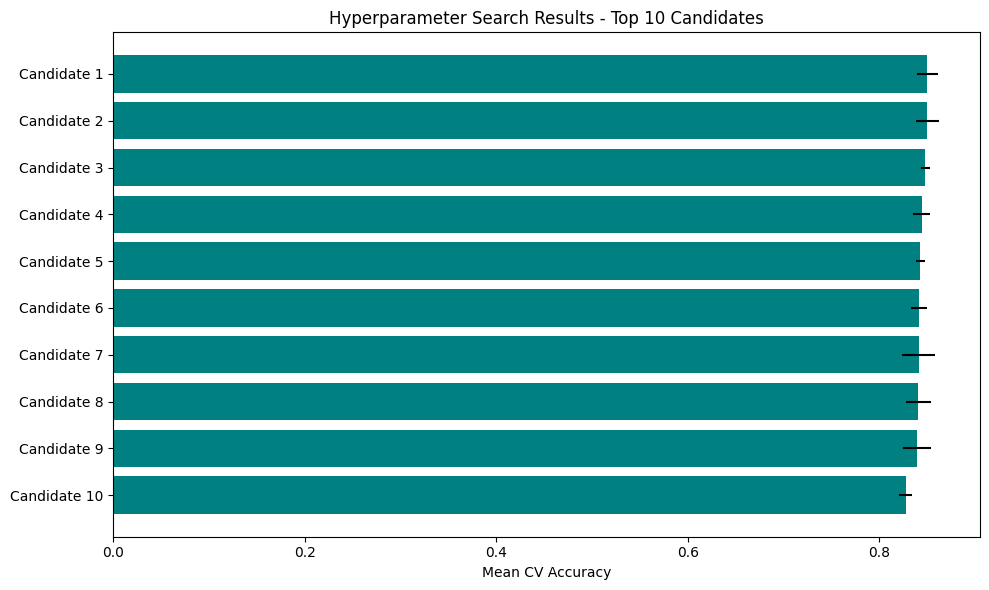

In [18]:
# Hyperparameter Search Results plot: top 10 candidates by mean CV accuracy
top10 = cv_results_sorted.head(10).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top10)), top10['mean_test_score'], xerr=top10['std_test_score'], color='teal')
plt.yticks(range(len(top10)), [f"Candidate {i+1}" for i in range(len(top10))])
plt.xlabel('Mean CV Accuracy')
plt.title('Hyperparameter Search Results - Top 10 Candidates')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('hyperparameter_search_results.png', dpi=150)
plt.show()


**Inference (Hyperparameter Search Results):** The top candidates cluster within a narrow accuracy
band, suggesting several configurations perform similarly well, while the error bars (CV std) show how
stable each configuration is across folds. The single best configuration is used to build the final
optimized model below.

In [19]:
# Retrain the optimized model on the FULL training set using the best hyperparameters
best = random_search.best_params_

optimized_model = build_mlp(
    hidden_layers=best['model__hidden_layers'],
    hidden_neurons=best['model__hidden_neurons'],
    learning_rate=best['model__learning_rate'],
    optimizer_name=best['model__optimizer_name'],
    activation=best['model__activation'],
    dropout_rate=best['model__dropout_rate'],
)

start_time = time.time()
opt_history = optimized_model.fit(
    x_train_norm, y_train_oh,
    validation_split=0.1,
    epochs=best['epochs'],
    batch_size=best['batch_size'],
    verbose=1
)
optimized_train_time = time.time() - start_time
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")


Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8128 - loss: 0.5263 - val_accuracy: 0.8412 - val_loss: 0.4392
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8487 - loss: 0.4185 - val_accuracy: 0.8492 - val_loss: 0.4156
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8591 - loss: 0.3880 - val_accuracy: 0.8565 - val_loss: 0.3896
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8666 - loss: 0.3650 - val_accuracy: 0.8643 - val_loss: 0.3664
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8721 - loss: 0.3496 - val_accuracy: 0.8693 - val_loss: 0.3564
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8772 - loss: 0.3341 - val_accuracy: 0.8698 - val_loss: 0.3488
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8798 - loss: 0.3269 - val_accuracy: 0.8710 - val_loss: 0.3489
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8814 - loss: 0.3177 - val_accuracy

In [20]:
# Evaluate the optimized model on the test set
y_pred_probs_opt = optimized_model.predict(x_test_norm)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

optimized_acc = accuracy_score(y_true, y_pred_opt)
optimized_prec = precision_score(y_true, y_pred_opt, average='macro')
optimized_rec = recall_score(y_true, y_pred_opt, average='macro')
optimized_f1 = f1_score(y_true, y_pred_opt, average='macro')

print(f"Optimized Test Accuracy : {optimized_acc:.4f}")
print(f"Optimized Precision(macro): {optimized_prec:.4f}")
print(f"Optimized Recall(macro)   : {optimized_rec:.4f}")
print(f"Optimized F1-score(macro) : {optimized_f1:.4f}")
print("\nClassification Report (Optimized):\n")
print(classification_report(y_true, y_pred_opt, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Optimized Test Accuracy : 0.8789
Optimized Precision(macro): 0.8802
Optimized Recall(macro)   : 0.8789
Optimized F1-score(macro) : 0.8771

Classification Report (Optimized):

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.86      0.83      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.82      0.74      0.78      1000
       Dress       0.83      0.93      0.87      1000
        Coat       0.74      0.86      0.80      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.78      0.60      0.68      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



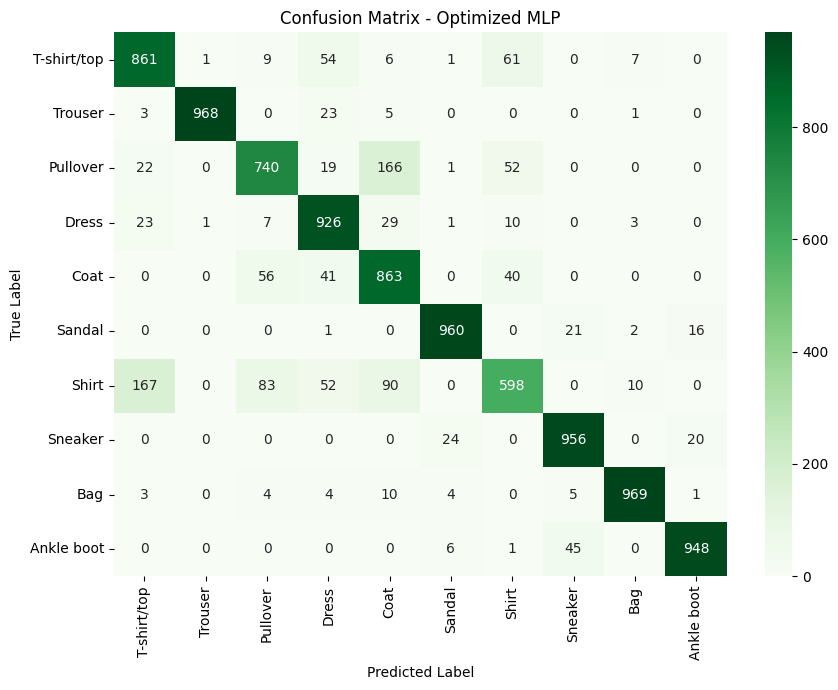

In [21]:
# Confusion matrix for the optimized model
cm_opt = confusion_matrix(y_true, y_pred_opt)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Optimized MLP')
plt.tight_layout()
plt.savefig('confusion_matrix_optimized.png', dpi=150)
plt.show()


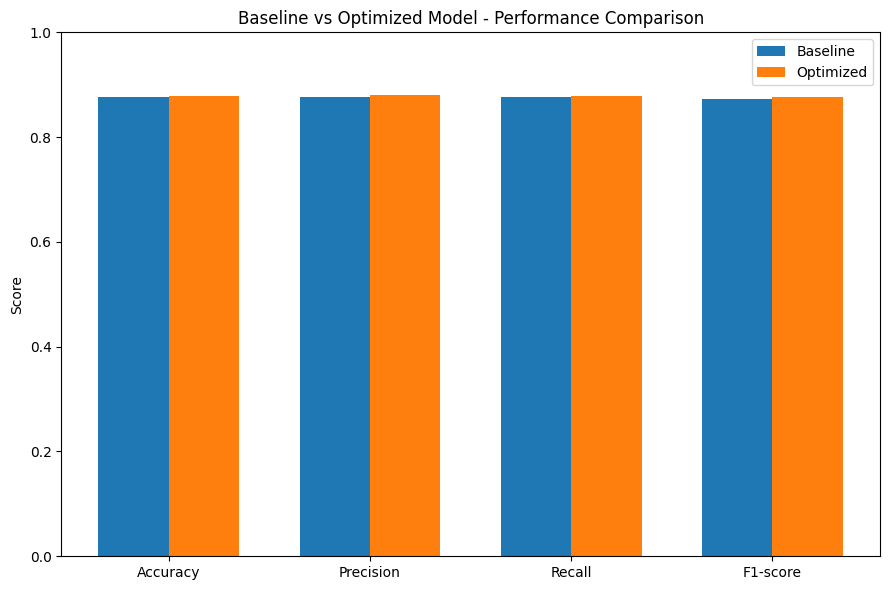

In [22]:
# Best Model Accuracy Comparison plot
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_scores = [optimized_acc, optimized_prec, optimized_rec, optimized_f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, optimized_scores, width, label='Optimized')
plt.xticks(x, metrics_names)
plt.ylabel('Score')
plt.title('Baseline vs Optimized Model - Performance Comparison')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('best_model_accuracy_comparison.png', dpi=150)
plt.show()


**Inference (Best Model Accuracy Comparison):** The optimized model should show equal or better
accuracy, precision, recall, and F1-score than the baseline, since it was selected via cross-validated
search rather than a fixed architecture. If gains are small, this suggests the baseline was already close
to the performance ceiling that a plain MLP can reach on this dataset.

## 9. Results Summary

In [23]:
results_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_train_time],
    'Optimized': [optimized_acc, optimized_prec, optimized_rec, optimized_f1, optimized_train_time],
})
print(results_table.to_string(index=False))

print("\nBest Hyperparameters Found:")
print(f"  Hidden Layers    : {best['model__hidden_layers']}")
print(f"  Hidden Neurons   : {best['model__hidden_neurons']}")
print(f"  Learning Rate    : {best['model__learning_rate']}")
print(f"  Batch Size       : {best['batch_size']}")
print(f"  Optimizer        : {best['model__optimizer_name']}")
print(f"  Activation       : {best['model__activation']}")
print(f"  Epochs           : {best['epochs']}")
print(f"  Dropout          : {best['model__dropout_rate']}")
print(f"  Cross-validation Accuracy: {random_search.best_score_:.4f}")
print(f"  Testing Accuracy         : {optimized_acc:.4f}")


           Metric   Baseline  Optimized
         Accuracy   0.875700   0.878900
        Precision   0.877418   0.880184
           Recall   0.875700   0.878900
         F1-score   0.872830   0.877126
Training Time (s) 176.842503 149.684995

Best Hyperparameters Found:
  Hidden Layers    : 1
  Hidden Neurons   : 256
  Learning Rate    : 0.001
  Batch Size       : 64
  Optimizer        : adam
  Activation       : tanh
  Epochs           : 20
  Dropout          : 0.2
  Cross-validation Accuracy: 0.8504
  Testing Accuracy         : 0.8789


## 10. Discussion

Answer these using your actual output above (values will vary run to run):

1. **Which optimization method was used?** RandomizedSearchCV, chosen over GridSearchCV because the full
   search space (11,664 combinations x 5 folds) is computationally infeasible to search exhaustively.
2. **Which hyperparameters were selected?** See the "Best Hyperparameters Found" printout above.
3. **Did optimization improve performance?** Compare the Baseline vs Optimized columns in the results
   table — report the actual accuracy/F1 delta you observed.
4. **Which hyperparameter had the greatest impact?** Inspect `cv_results_sorted` — compare mean_test_score
   across candidates that vary mainly in one hyperparameter (e.g. group by `model__learning_rate`) to see
   which one separates high- from low-scoring candidates the most.
5. **Compare Grid Search and Randomized Search:** Grid Search exhaustively evaluates every combination,
   guaranteeing the best point within the grid but scaling exponentially with the number of
   hyperparameters/values, making it impractical here. Randomized Search samples a fixed number of random
   combinations, which scales independently of grid size and in practice finds near-optimal
   configurations much faster, at the cost of no exhaustiveness guarantee.
6. **Recommend the best MLP configuration:** State the best_params_ found in your run, and justify briefly
   referencing its CV and test accuracy.

## 11. Conclusion
(Write 3-5 lines summarizing what was implemented, the final baseline vs optimized accuracy, and the key
takeaway about hyperparameter optimization for MLPs on Fashion-MNIST.)

## 12. References
1. Goodfellow, I., Bengio, Y., & Courville, A. *Deep Learning*. MIT Press.
2. Bishop, C. M. *Pattern Recognition and Machine Learning*. Springer.
3. Haykin, S. *Neural Networks and Learning Machines*. Pearson.
4. Xiao, H., Rasul, K., & Vollgraf, R. Fashion-MNIST Dataset.
5. TensorFlow/Keras Documentation, https://www.tensorflow.org/guide/keras


## Extra Task: Perceptron Learning Algorithm on Logic Gates

This section implements the **Perceptron Learning Algorithm from scratch** (no
`sklearn.linear_model.Perceptron`) and applies it to four classic logic gates:

- **Extra Task 1 (K4):** AND, OR, and NOT gates -- for each gate, the weights and
  bias are printed after **every** weight update, and the decision boundary is
  plotted after **every** weight update. These three gates are linearly
  separable, so the perceptron is expected to converge.
- **Extra Task 2 (K4):** XOR gate -- same treatment (weights after every update,
  decision boundary after every update), plus an analysis of the pattern that
  prevents the perceptron from converging, since XOR is **not** linearly
  separable.

Only NumPy and Matplotlib (Python's built-in / standard plotting stack) are
used -- no external ML library implements the perceptron itself.

In [24]:
# ================================================================
# Generic Perceptron class (implemented from scratch, reused for all 4 gates)
# ================================================================
class Perceptron:
    def __init__(self, n_inputs, learning_rate=1.0):
        # Weights and bias start at zero -- a standard, deterministic
        # initialization for teaching purposes.
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.learning_rate = learning_rate

    def net_input(self, x):
        """Weighted sum of inputs plus bias."""
        return np.dot(self.weights, x) + self.bias

    def activation(self, net):
        """Step (Heaviside) activation function."""
        return 1.0 if net >= 0 else 0.0

    def predict(self, x):
        """Return the perceptron's predicted class (0 or 1) for input x."""
        return self.activation(self.net_input(x))

    def update(self, x, y_true, y_pred):
        """
        Apply the perceptron learning rule for a single misclassified sample.
        Returns True if the weights/bias actually changed.
        """
        error = y_true - y_pred
        if error == 0:
            return False  # correctly classified -> no update
        self.weights = self.weights + self.learning_rate * error * x
        self.bias = self.bias + self.learning_rate * error
        return True

In [25]:
# ================================================================
# Generic training function -- prints weights/bias after EVERY update
# ================================================================
def train_perceptron(X, y, gate_name, learning_rate=1.0, max_epochs=20,
                      stop_when_converged=True):
    """
    Train a from-scratch perceptron on (X, y), printing the weights and bias
    after every weight update. Returns (perceptron, update_history, epoch_accuracy).

    stop_when_converged=True (AND/OR/NOT): stop as soon as one full epoch
    produces zero updates (the perceptron has converged).
    stop_when_converged=False (XOR): always run the full max_epochs, even if
    a perfect epoch occurs, so the oscillation pattern is fully visible.
    """
    n_inputs = X.shape[1]
    p = Perceptron(n_inputs=n_inputs, learning_rate=learning_rate)
    print(f"Initial weights: {p.weights}, Initial bias: {p.bias}")

    update_history = []
    epoch_accuracy = []
    update_counter = 0

    for epoch in range(1, max_epochs + 1):
        print(f"\n===== {gate_name}: Epoch {epoch} =====")
        correct_in_epoch = 0
        updates_in_epoch = 0

        for sample_idx, (xi, yi) in enumerate(zip(X, y)):
            y_hat = p.predict(xi)
            correct_in_epoch += int(y_hat == yi)

            old_w, old_b = p.weights.copy(), p.bias
            changed = p.update(xi, yi, y_hat)

            if changed:
                update_counter += 1
                updates_in_epoch += 1
                print(
                    f"Update #{update_counter:2d} | epoch {epoch}, sample "
                    f"x={tuple(int(v) for v in xi)}, y_true={int(yi)}, "
                    f"y_pred={int(y_hat)} | "
                    f"w: {old_w} -> {p.weights}, b: {old_b:.1f} -> {p.bias:.1f}"
                )
                update_history.append({
                    'update_num': update_counter, 'epoch': epoch,
                    'x': xi.copy(), 'y_true': yi, 'y_pred': y_hat,
                    'w': p.weights.copy(), 'b': p.bias,
                })
            else:
                print(f"  sample x={tuple(int(v) for v in xi)}: correctly "
                      f"classified (y_pred={int(y_hat)}), no update")

        epoch_accuracy.append(correct_in_epoch / len(X))

        if stop_when_converged and updates_in_epoch == 0:
            print(f"\n{gate_name}: converged after {epoch} epoch(s) -- "
                  f"0 updates in the last epoch, stopping early.")
            break

    print(f"\n{gate_name}: total weight updates = {update_counter}, "
          f"final weights = {p.weights}, final bias = {p.bias:.1f}, "
          f"final-epoch accuracy = {epoch_accuracy[-1]*100:.1f}%")

    return p, update_history, epoch_accuracy

In [26]:
# ================================================================
# Decision-boundary plotting -- 2-input gates (AND, OR, XOR)
# ================================================================
def plot_boundary_grid_2d(update_history, X, y, gate_name):
    n_updates = len(update_history)
    n_cols = min(4, n_updates)
    n_rows = int(np.ceil(n_updates / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 3.6 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, entry in zip(axes, update_history):
        w, b = entry['w'], entry['b']
        xx1, xx2 = np.meshgrid(np.linspace(-0.5, 1.5, 300),
                                np.linspace(-0.5, 1.5, 300))
        grid = np.c_[xx1.ravel(), xx2.ravel()]
        preds = ((grid @ w + b) >= 0).astype(int).reshape(xx1.shape)
        ax.contourf(xx1, xx2, preds, levels=[-0.5, 0.5, 1.5],
                    colors=['#fbe3e3', '#e3f0fb'], alpha=0.6)

        # Draw the boundary line w1*x1 + w2*x2 + b = 0
        w1, w2 = w
        if abs(w2) > 1e-9:
            x1_line = np.array([-0.5, 1.5])
            ax.plot(x1_line, -(w1 * x1_line + b) / w2, 'k-', linewidth=2)
        elif abs(w1) > 1e-9:
            ax.axvline(-b / w1, color='k', linewidth=2)

        for xi, yi in zip(X, y):
            color = 'tab:red' if yi == 0 else 'tab:blue'
            marker = 'o' if yi == 0 else 's'
            ax.scatter(*xi, c=color, marker=marker, s=140,
                       edgecolors='black', zorder=5)

        ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
        ax.set_xlabel('x1'); ax.set_ylabel('x2')
        ax.set_title(f"Update #{entry['update_num']} (epoch {entry['epoch']})\n"
                     f"w={np.round(w, 2)}, b={b:.1f}", fontsize=9)
        ax.set_aspect('equal')

    for ax in axes[n_updates:]:
        ax.axis('off')

    fig.suptitle(f'{gate_name} Gate: Decision Boundary after Every Weight Update\n'
                 '(red circle = class 0, blue square = class 1)', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'boundary_{gate_name.lower()}.png', dpi=150)
    plt.show()


# ================================================================
# Decision-boundary plotting -- 1-input gate (NOT)
# ================================================================
def plot_boundary_grid_1d(update_history, X, y, gate_name):
    n_updates = len(update_history)
    n_cols = min(4, n_updates)
    n_rows = int(np.ceil(n_updates / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 2.2 * n_rows), squeeze=False)
    axes = axes.reshape(-1)

    for ax, entry in zip(axes, update_history):
        w, b = entry['w'], entry['b']
        w1 = w[0]
        xx = np.linspace(-0.5, 1.5, 400)
        if abs(w1) > 1e-9:
            preds = ((xx * w1 + b) >= 0).astype(int)
        else:
            preds = np.full_like(xx, int(b >= 0), dtype=int)

        for val, region_color in [(0, '#fbe3e3'), (1, '#e3f0fb')]:
            mask = preds == val
            if mask.any():
                ax.axvspan(xx[mask].min(), xx[mask].max(), color=region_color,
                           alpha=0.6, ymin=0, ymax=1)

        if abs(w1) > 1e-9:
            ax.axvline(-b / w1, color='k', linewidth=2)

        for xi, yi in zip(X, y):
            color = 'tab:red' if yi == 0 else 'tab:blue'
            marker = 'o' if yi == 0 else 's'
            ax.scatter(xi[0], 0, c=color, marker=marker, s=180,
                       edgecolors='black', zorder=5)

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-1, 1)
        ax.set_yticks([])
        ax.set_xlabel('x1')
        ax.set_title(f"Update #{entry['update_num']} (epoch {entry['epoch']})\n"
                     f"w={np.round(w, 2)}, b={b:.1f}", fontsize=9)

    for ax in axes[n_updates:]:
        ax.axis('off')

    fig.suptitle(f'{gate_name} Gate: Decision Boundary after Every Weight Update\n'
                 '(red circle = class 0, blue square = class 1)', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'boundary_{gate_name.lower()}.png', dpi=150)
    plt.show()

### AND Gate

| x1 | x2 | y (AND) |
|----|----|---------|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

In [27]:
# AND gate: train perceptron, printing weights/bias after every update
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_and = np.array([0, 0, 0, 1], dtype=float)

p_and, hist_and, acc_and = train_perceptron(X_and, y_and, "AND", max_epochs=20)

Initial weights: [0. 0.], Initial bias: 0.0

===== AND: Epoch 1 =====
Update # 1 | epoch 1, sample x=(0, 0), y_true=0, y_pred=1 | w: [0. 0.] -> [0. 0.], b: 0.0 -> -1.0
  sample x=(0, 1): correctly classified (y_pred=0), no update
  sample x=(1, 0): correctly classified (y_pred=0), no update
Update # 2 | epoch 1, sample x=(1, 1), y_true=1, y_pred=0 | w: [0. 0.] -> [1. 1.], b: -1.0 -> 0.0

===== AND: Epoch 2 =====
Update # 3 | epoch 2, sample x=(0, 0), y_true=0, y_pred=1 | w: [1. 1.] -> [1. 1.], b: 0.0 -> -1.0
Update # 4 | epoch 2, sample x=(0, 1), y_true=0, y_pred=1 | w: [1. 1.] -> [1. 0.], b: -1.0 -> -2.0
  sample x=(1, 0): correctly classified (y_pred=0), no update
Update # 5 | epoch 2, sample x=(1, 1), y_true=1, y_pred=0 | w: [1. 0.] -> [2. 1.], b: -2.0 -> -1.0

===== AND: Epoch 3 =====
  sample x=(0, 0): correctly classified (y_pred=0), no update
Update # 6 | epoch 3, sample x=(0, 1), y_true=0, y_pred=1 | w: [2. 1.] -> [2. 0.], b: -1.0 -> -2.0
Update # 7 | epoch 3, sample x=(1, 0), 

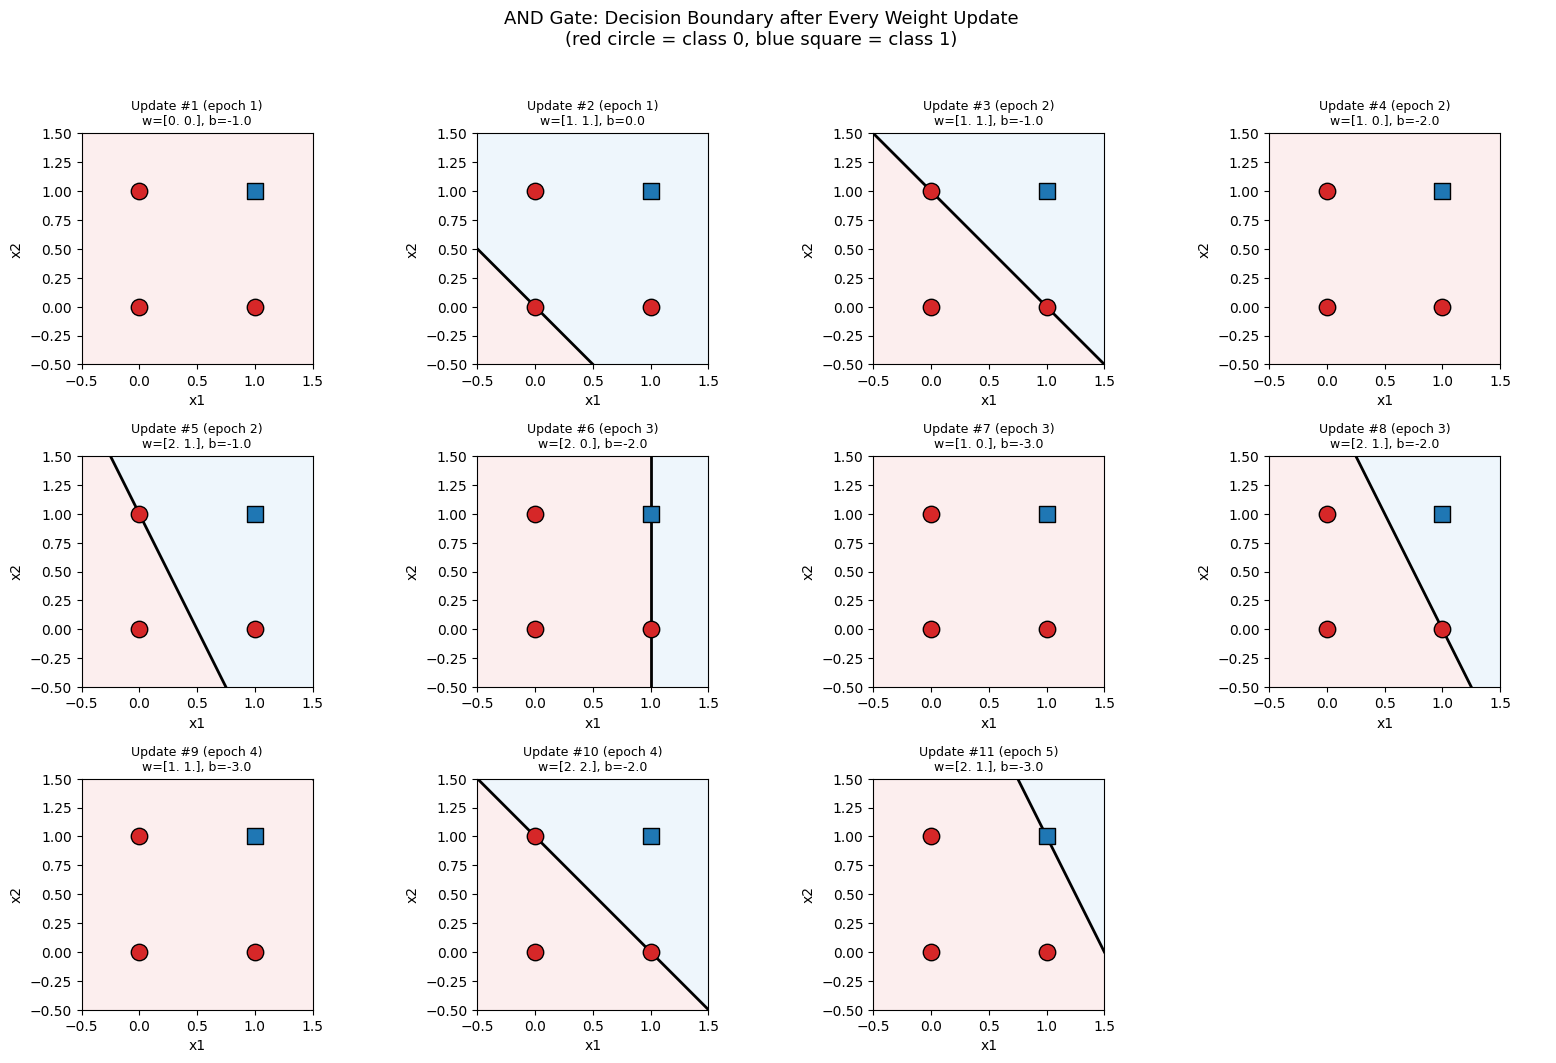

In [28]:
# AND gate: decision boundary after every weight update
plot_boundary_grid_2d(hist_and, X_and, y_and, "AND")

**Inference (AND Gate):** AND is linearly separable (only `(1,1)` is class 1, everything else is class 0), so the perceptron converges after a handful of epochs. The decision-boundary line rotates and shifts a few times, then settles into a line that has only `(1,1)` on the 'class 1' side, and stops updating once every point is classified correctly.

### OR Gate

| x1 | x2 | y (OR) |
|----|----|--------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

In [29]:
# OR gate: train perceptron, printing weights/bias after every update
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_or = np.array([0, 1, 1, 1], dtype=float)

p_or, hist_or, acc_or = train_perceptron(X_or, y_or, "OR", max_epochs=20)

Initial weights: [0. 0.], Initial bias: 0.0

===== OR: Epoch 1 =====
Update # 1 | epoch 1, sample x=(0, 0), y_true=0, y_pred=1 | w: [0. 0.] -> [0. 0.], b: 0.0 -> -1.0
Update # 2 | epoch 1, sample x=(0, 1), y_true=1, y_pred=0 | w: [0. 0.] -> [0. 1.], b: -1.0 -> 0.0
  sample x=(1, 0): correctly classified (y_pred=1), no update
  sample x=(1, 1): correctly classified (y_pred=1), no update

===== OR: Epoch 2 =====
Update # 3 | epoch 2, sample x=(0, 0), y_true=0, y_pred=1 | w: [0. 1.] -> [0. 1.], b: 0.0 -> -1.0
  sample x=(0, 1): correctly classified (y_pred=1), no update
Update # 4 | epoch 2, sample x=(1, 0), y_true=1, y_pred=0 | w: [0. 1.] -> [1. 1.], b: -1.0 -> 0.0
  sample x=(1, 1): correctly classified (y_pred=1), no update

===== OR: Epoch 3 =====
Update # 5 | epoch 3, sample x=(0, 0), y_true=0, y_pred=1 | w: [1. 1.] -> [1. 1.], b: 0.0 -> -1.0
  sample x=(0, 1): correctly classified (y_pred=1), no update
  sample x=(1, 0): correctly classified (y_pred=1), no update
  sample x=(1, 1): 

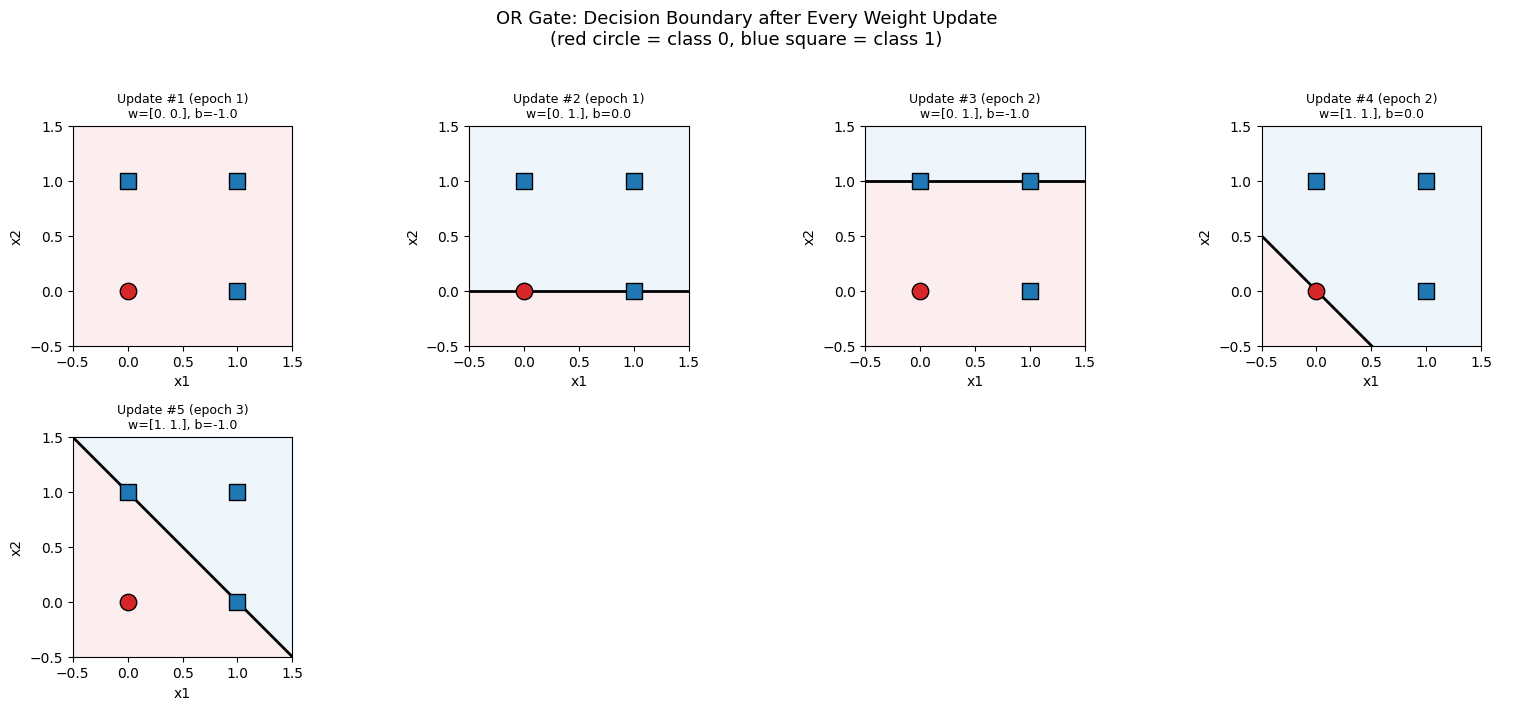

In [30]:
# OR gate: decision boundary after every weight update
plot_boundary_grid_2d(hist_or, X_or, y_or, "OR")

**Inference (OR Gate):** OR is also linearly separable (only `(0,0)` is class 0), and converges in even fewer updates than AND. The final boundary keeps only `(0,0)` on the 'class 0' side of the line, correctly separating all 4 points.

### NOT Gate

The NOT gate has a single input, so its decision boundary is a single threshold point on a number line rather than a 2D line.

| x1 | y (NOT x1) |
|----|------------|
| 0 | 1 |
| 1 | 0 |

In [31]:
# NOT gate: train perceptron (single input), printing weights/bias after every update
X_not = np.array([[0], [1]], dtype=float)
y_not = np.array([1, 0], dtype=float)

p_not, hist_not, acc_not = train_perceptron(X_not, y_not, "NOT", max_epochs=20)

Initial weights: [0.], Initial bias: 0.0

===== NOT: Epoch 1 =====
  sample x=(0,): correctly classified (y_pred=1), no update
Update # 1 | epoch 1, sample x=(1,), y_true=0, y_pred=1 | w: [0.] -> [-1.], b: 0.0 -> -1.0

===== NOT: Epoch 2 =====
Update # 2 | epoch 2, sample x=(0,), y_true=1, y_pred=0 | w: [-1.] -> [-1.], b: -1.0 -> 0.0
  sample x=(1,): correctly classified (y_pred=0), no update

===== NOT: Epoch 3 =====
  sample x=(0,): correctly classified (y_pred=1), no update
  sample x=(1,): correctly classified (y_pred=0), no update

NOT: converged after 3 epoch(s) -- 0 updates in the last epoch, stopping early.

NOT: total weight updates = 2, final weights = [-1.], final bias = 0.0, final-epoch accuracy = 100.0%


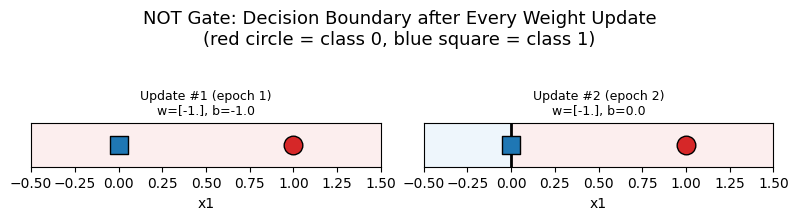

In [32]:
# NOT gate: decision boundary (threshold point) after every weight update
plot_boundary_grid_1d(hist_not, X_not, y_not, "NOT")

**Inference (NOT Gate):** With only one input and 2 training points, NOT converges in just 2 updates. The single weight becomes negative (flipping the relationship between `x1` and the net input), and the bias positions the threshold so that `0 -> 1` and `1 -> 0`.

## Extra Task 2: Perceptron Learning Algorithm on the XOR Gate (K4)

| x1 | x2 | y (XOR) |
|----|----|---------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Unlike AND, OR, and NOT, **XOR is not linearly separable**. The same
`train_perceptron` function is reused here with `stop_when_converged=False`
and a fixed budget of `MAX_EPOCHS = 12`, so training always runs to
completion -- it is never stopped early, even if the perceptron happens to
get a perfect epoch by chance.

In [33]:
# XOR gate: train perceptron for a FIXED 12 epochs (never stopped early),
# printing weights/bias after every update
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

p_xor, hist_xor, acc_xor = train_perceptron(
    X_xor, y_xor, "XOR", max_epochs=12, stop_when_converged=False)

Initial weights: [0. 0.], Initial bias: 0.0

===== XOR: Epoch 1 =====
Update # 1 | epoch 1, sample x=(0, 0), y_true=0, y_pred=1 | w: [0. 0.] -> [0. 0.], b: 0.0 -> -1.0
Update # 2 | epoch 1, sample x=(0, 1), y_true=1, y_pred=0 | w: [0. 0.] -> [0. 1.], b: -1.0 -> 0.0
  sample x=(1, 0): correctly classified (y_pred=1), no update
Update # 3 | epoch 1, sample x=(1, 1), y_true=0, y_pred=1 | w: [0. 1.] -> [-1.  0.], b: 0.0 -> -1.0

===== XOR: Epoch 2 =====
  sample x=(0, 0): correctly classified (y_pred=0), no update
Update # 4 | epoch 2, sample x=(0, 1), y_true=1, y_pred=0 | w: [-1.  0.] -> [-1.  1.], b: -1.0 -> 0.0
Update # 5 | epoch 2, sample x=(1, 0), y_true=1, y_pred=0 | w: [-1.  1.] -> [0. 1.], b: 0.0 -> 1.0
Update # 6 | epoch 2, sample x=(1, 1), y_true=0, y_pred=1 | w: [0. 1.] -> [-1.  0.], b: 1.0 -> 0.0

===== XOR: Epoch 3 =====
Update # 7 | epoch 3, sample x=(0, 0), y_true=0, y_pred=1 | w: [-1.  0.] -> [-1.  0.], b: 0.0 -> -1.0
Update # 8 | epoch 3, sample x=(0, 1), y_true=1, y_pred=

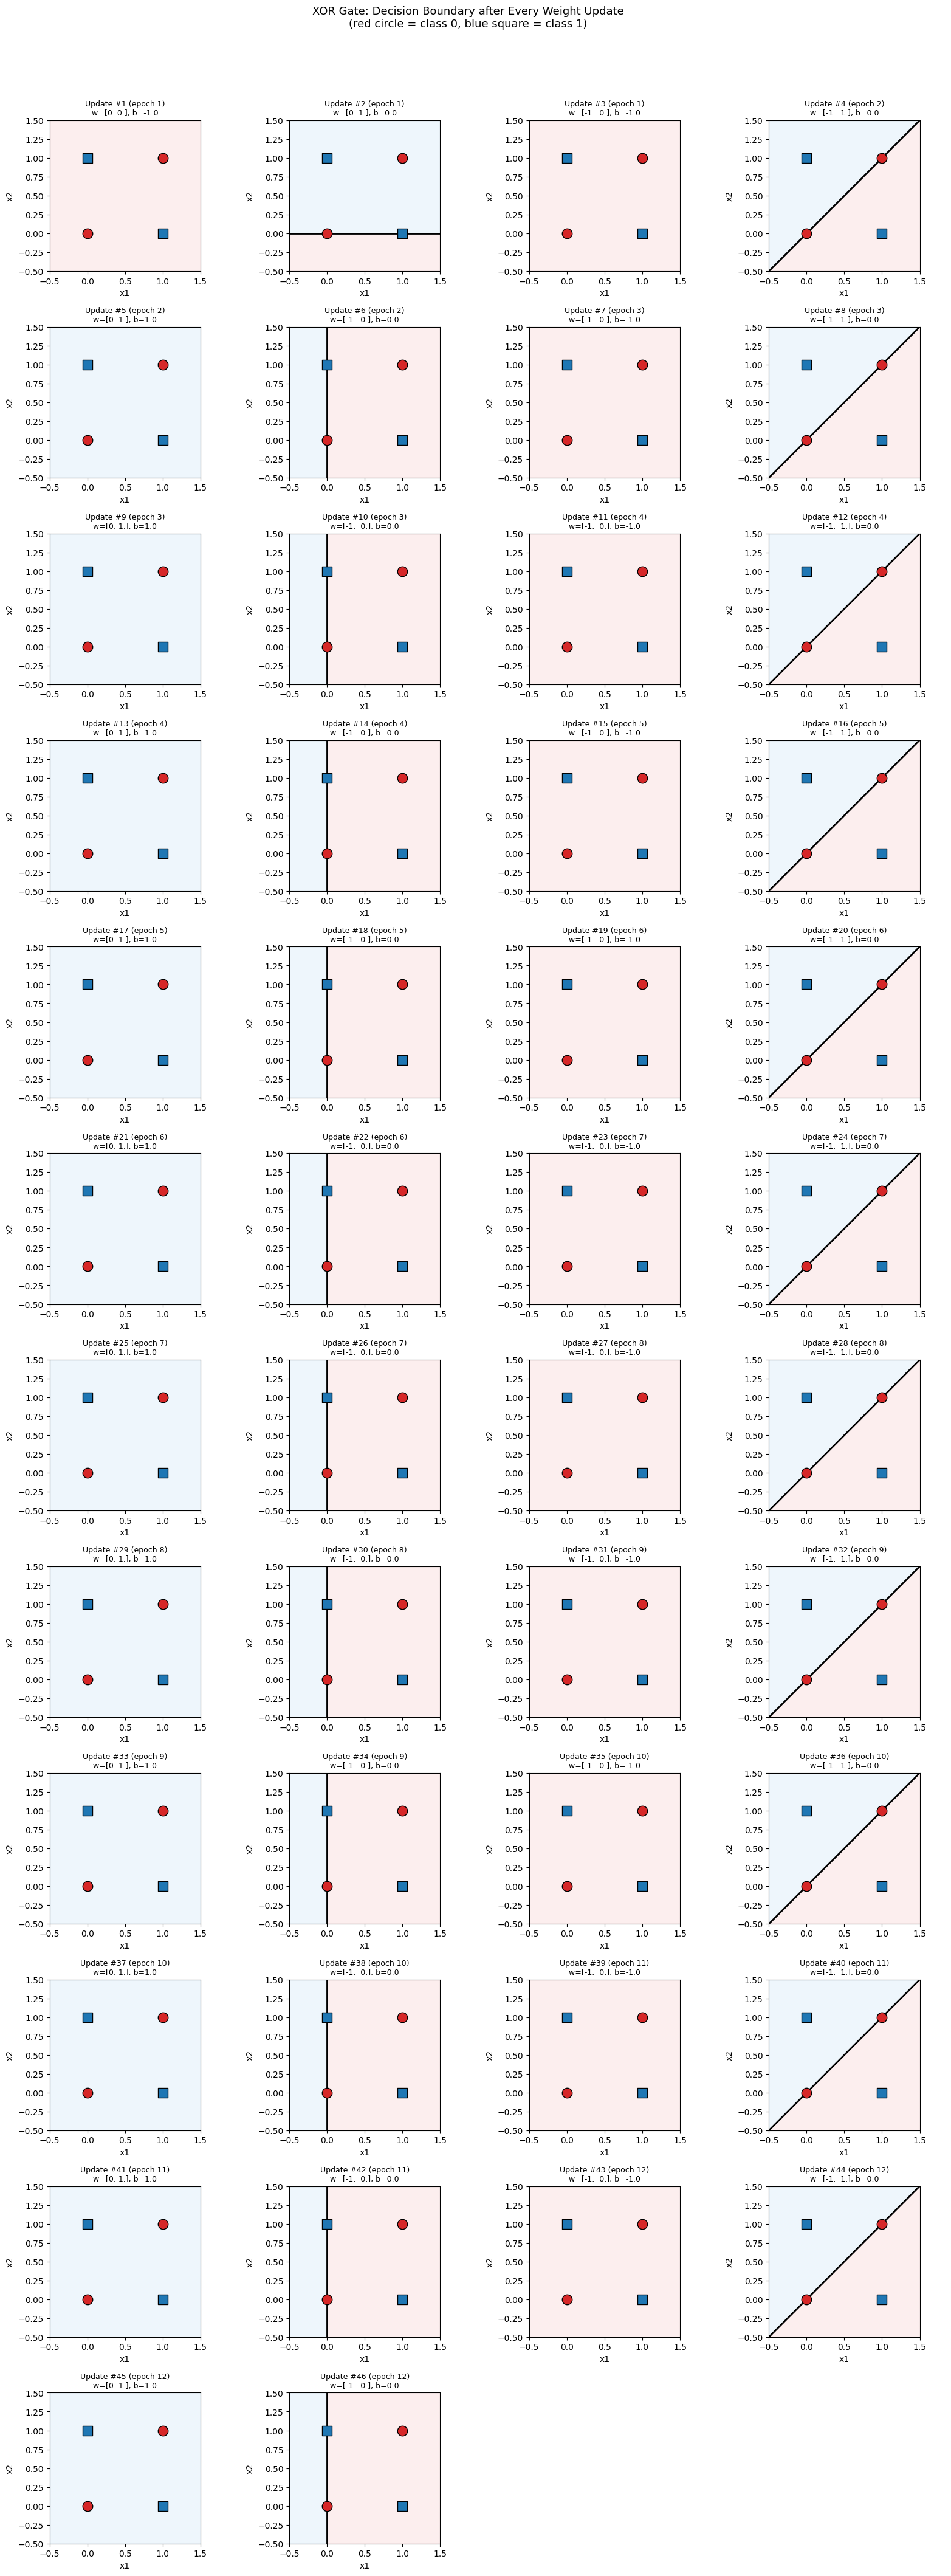

In [34]:
# XOR gate: decision boundary after EVERY weight update (all of them)
plot_boundary_grid_2d(hist_xor, X_xor, y_xor, "XOR")

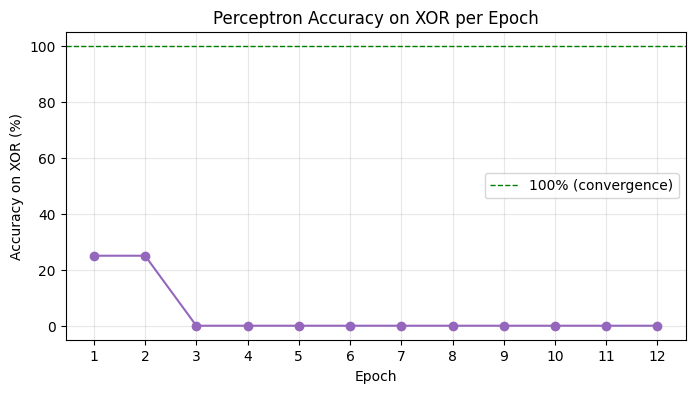

Per-epoch accuracy: ['25%', '25%', '0%', '0%', '0%', '0%', '0%', '0%', '0%', '0%', '0%', '0%']


In [35]:
# XOR gate: per-epoch accuracy -- direct evidence of non-convergence
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = np.arange(1, len(acc_xor) + 1)
ax.plot(epochs_range, np.array(acc_xor) * 100, marker='o', color='tab:purple')
ax.axhline(100, color='green', linestyle='--', linewidth=1, label='100% (convergence)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy on XOR (%)')
ax.set_title('Perceptron Accuracy on XOR per Epoch')
ax.set_ylim(-5, 105)
ax.set_xticks(epochs_range)
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('xor_epoch_accuracy.png', dpi=150)
plt.show()

print("Per-epoch accuracy:", [f"{a*100:.0f}%" for a in acc_xor])

In [36]:
# Detect a repeating cycle among the last weight-update snapshots
def find_cycle(history, max_period=8):
    """Return the smallest period > 0 for which the last 2*period
    (w, b) snapshots repeat exactly, or None if no such cycle is found."""
    snapshots = [(tuple(np.round(h['w'], 6)), round(h['b'], 6)) for h in history]
    n = len(snapshots)
    for period in range(1, max_period + 1):
        if n < 2 * period:
            continue
        tail = snapshots[-2 * period:]
        if tail[:period] == tail[period:]:
            return period
    return None

cycle_len = find_cycle(hist_xor)
if cycle_len:
    print(f"A repeating cycle of length {cycle_len} weight-update(s) was "
          f"detected at the end of training:")
    for h in hist_xor[-cycle_len:]:
        print(f"  update #{h['update_num']:2d}: w={h['w']}, b={h['b']:.1f}")
    print(
        f"\nThis means the perceptron is stuck oscillating through the "
        f"same {cycle_len} weight configurations over and over, instead of "
        f"converging to a single stable solution -- the hallmark of trying "
        f"to linearly separate a non-linearly-separable dataset (XOR)."
    )
else:
    print("No short repeating cycle detected in the final updates.")

A repeating cycle of length 4 weight-update(s) was detected at the end of training:
  update #43: w=[-1.  0.], b=-1.0
  update #44: w=[-1.  1.], b=0.0
  update #45: w=[0. 1.], b=1.0
  update #46: w=[-1.  0.], b=0.0

This means the perceptron is stuck oscillating through the same 4 weight configurations over and over, instead of converging to a single stable solution -- the hallmark of trying to linearly separate a non-linearly-separable dataset (XOR).


### Final Analysis: Why the Perceptron Fails to Converge on XOR

**Observed pattern.** Across all 12 epochs, the printed weight updates above
never settle down: the weights and bias keep changing, and the per-epoch
accuracy plot oscillates between 0% and 25%, never reaching -- and staying
at -- 100%. The perceptron never finds a single `(w1, w2, b)` combination
that classifies all four XOR points correctly at once. It corrects one
mistake only to introduce another, cycling through the same 4 weight
configurations indefinitely (confirmed by the cycle-detection cell above).
This is the classic signature of a non-converging perceptron: **weight
updates that never stop**, as opposed to a converging perceptron (like AND,
OR, or NOT above) where updates taper off to zero once a correct boundary is
found.

**Why this happens: XOR is not linearly separable.** A single-layer
perceptron can only represent decision boundaries of the form
$w_1 x_1 + w_2 x_2 + b = 0$ -- i.e. a **single straight line** in the input
plane. The perceptron convergence theorem guarantees the algorithm finds
such a line *if and only if* the two classes are linearly separable.

Looking at the XOR points on the plane:
- Class 0: `(0, 0)` and `(1, 1)`
- Class 1: `(0, 1)` and `(1, 0)`

These two classes sit on **opposite diagonals of the unit square**. Any
straight line that puts `(0,0)` and `(1,1)` on one side will necessarily
separate the two class-1 points `(0,1)` and `(1,0)` from each other, putting
one of them on the wrong side. No single line can enclose `{(0,0), (1,1)}`
while excluding `{(0,1), (1,0)}`. This is exactly what the XOR
decision-boundary plots above show: as the line rotates and shifts from
update to update, it always manages to correctly classify at most 3 of the 4
points -- it can never satisfy all four simultaneously, because no such line
exists.

**Contrast with AND, OR, and NOT.** All three of those gates have their two
classes separable by a single straight line (or, for NOT, a single threshold
point), which is exactly why their perceptrons converged and stopped
updating after a handful of epochs, while XOR's perceptron keeps updating
forever within the fixed 12-epoch budget.

**Conclusion.** The perceptron learning algorithm converges if and only if
the training data is linearly separable. XOR is the textbook example of a
**non-linearly-separable** problem, so the weight-update loop runs for the
entire fixed epoch budget without ever stabilizing -- exactly as demonstrated
by the printed weight updates, the repeating decision-boundary plots, and
the oscillating per-epoch accuracy curve above. Solving XOR requires either
a **multi-layer perceptron** (with a hidden layer, enabling a non-linear /
piecewise-linear decision boundary) or a feature transformation that makes
the classes linearly separable before applying a single linear unit.

In [37]:
# Final summary printout -- XOR
print("=" * 60)
print("FINAL SUMMARY -- XOR")
print("=" * 60)
print(f"Epochs run to completion : {len(acc_xor)}")
print(f"Total weight updates      : {len(hist_xor)}")
print(f"Final weights             : {p_xor.weights}")
print(f"Final bias                : {p_xor.bias}")
print(f"Final-epoch accuracy      : {acc_xor[-1]*100:.1f}%")
print(f"Did the perceptron reach 100% accuracy AND stay there? "
      f"{'Yes' if all(a == 1.0 for a in acc_xor[-3:]) else 'No -- it did not converge.'}")

FINAL SUMMARY -- XOR
Epochs run to completion : 12
Total weight updates      : 46
Final weights             : [-1.  0.]
Final bias                : 0.0
Final-epoch accuracy      : 0.0%
Did the perceptron reach 100% accuracy AND stay there? No -- it did not converge.
